## Friedman vs non-friedman comparisons

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

import sys; sys.path.append('..')

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)
plt.rcParams.update({'font.size': 30, 'pdf.fonttype' : 42, 'ps.fonttype' : 42})

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

rdir  = '../../results/black-box/'
figdir = f'../figs/black-box/'
datadir = '../../datasets/blackbox/' # Set to path to datasets

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')

In [2]:
df_results = pd.read_feather(rdir+'results.feather')
df_sum = pd.read_csv(rdir+'results-summary.csv.gz', compression='gzip')

print('mean trial count:')
print(df_results.groupby('algorithm')['dataset'].count().sort_values()
      / df_results.dataset.nunique())

mean trial count:
algorithm
eql          0.666667
PS-Tree      1.000000
Operon       1.833333
brush        2.333333
tir          2.500000
afp          2.666667
eplex        2.833333
FEAT         2.916667
gplearn      2.916667
FFX          3.000000
itea         3.000000
qlattice     3.000000
rils-rols    3.000000
Name: dataset, dtype: float64


saving ../figs/black-box//hist1_Friedman.pdf
saving ../figs/black-box//hist5_Friedman.pdf
saving ../figs/black-box//hist1_Non-Friedman.pdf
saving ../figs/black-box//hist5_Non-Friedman.pdf


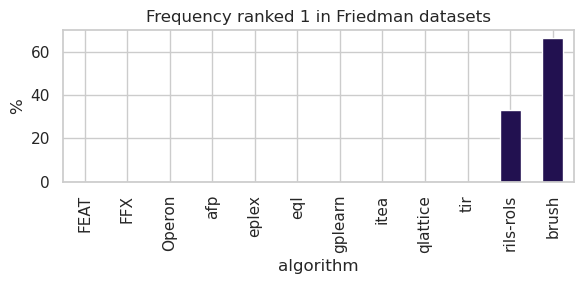

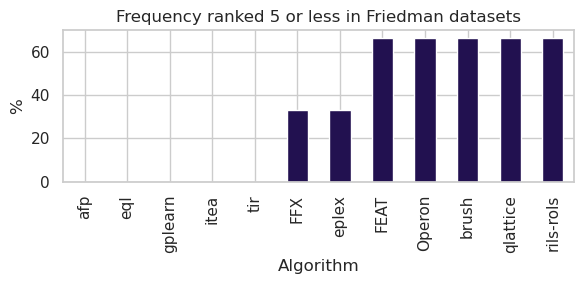

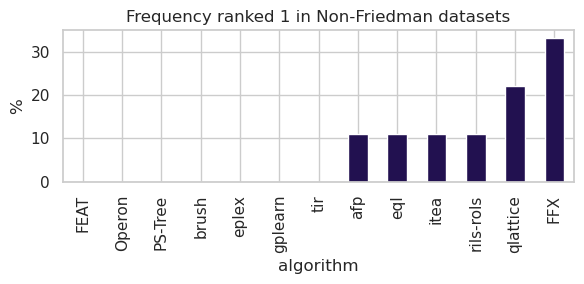

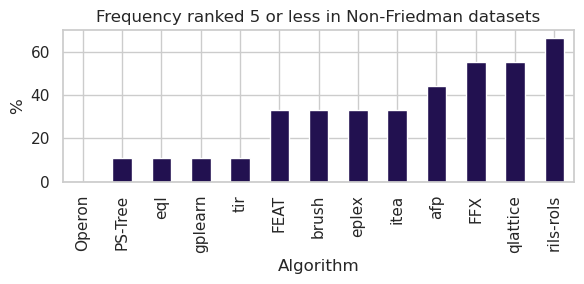

In [3]:
for (data, name) in [
    (df_sum[df_sum.dataset.str.contains("_fri_")].copy(), 'Friedman'),
    (df_sum[~df_sum.dataset.str.contains("_fri_")].copy(), 'Non-Friedman'),
]:

    df_pivot = pd.pivot_table(
        data,index='algorithm', columns=['dataset'], values='r2_test'
    ).apply(lambda x: np.round(x,4))

    ranks = df_pivot.rank(ascending=False, method='min')
    n = len(ranks.columns)

    fig = plt.figure(figsize=(6,3))
    ranks.apply(
        lambda xs: np.array([100.0/n if x < 2 else 0 for x in xs]).sum(), axis=1
    ).sort_values().plot.bar(
        ylabel='%',
        title=f'Frequency ranked 1 in {name} datasets'
    )
    save(name=f"hist1_{name}")

    fig = plt.figure(figsize=(6,3))
    ranks.apply(
        lambda xs: np.array([100.0/n if x < 5 else 0 for x in xs]).sum(), axis=1
    ).sort_values().plot.bar(
        ylabel='%',
        xlabel='Algorithm',
        title=f'Frequency ranked 5 or less in {name} datasets'
    )
    save(name=f"hist5_{name}")

## Pointplots

saving ../figs/black-box//pairgrid-pointplot_Friedman_r2_test_model_size_training-time-(s).pdf
saving ../figs/black-box//pairgrid-pointplot_Non-Friedman_r2_test_model_size_training-time-(s).pdf


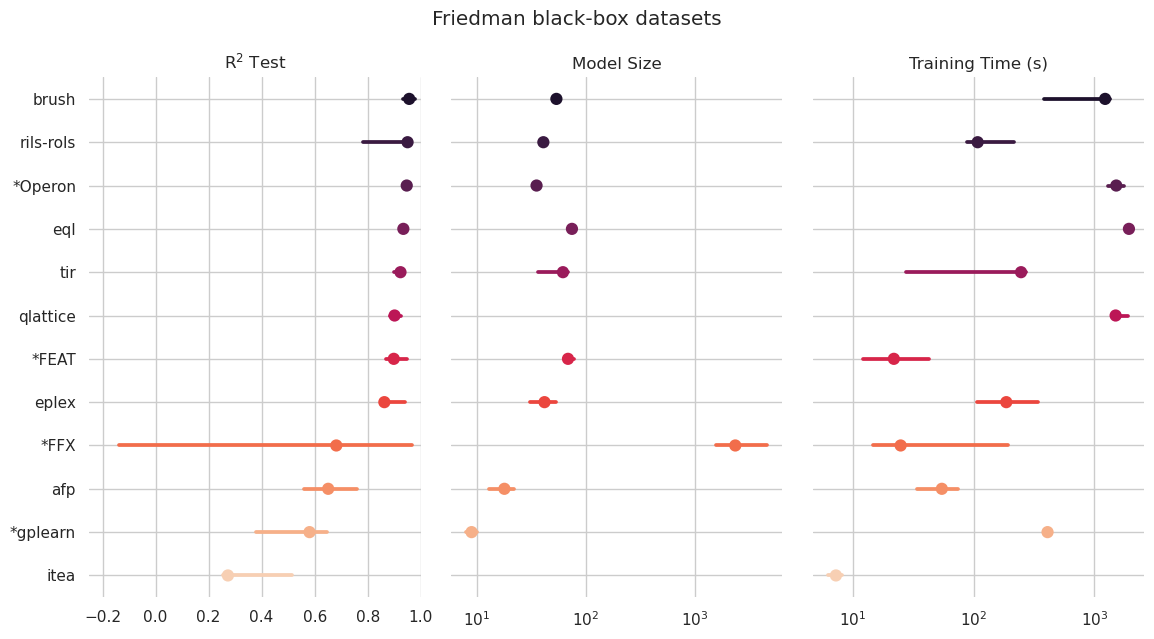

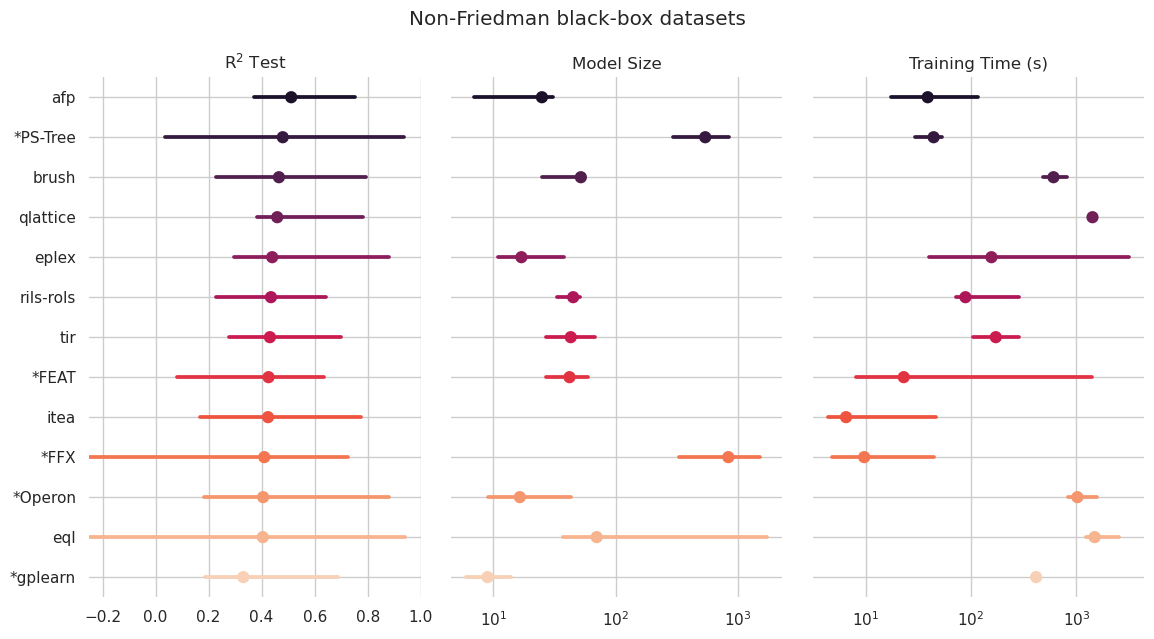

In [4]:
for (data, name) in [
    (df_sum[df_sum.dataset.str.contains("_fri_")].copy(), 'Friedman'),
    (df_sum[~df_sum.dataset.str.contains("_fri_")].copy(), 'Non-Friedman'),
]:
    # different options
    x_vars=[
    #       'rmse_test',
    #         'log_mse_test',
    #         'r2_test_norm',
            'r2_test',
    #         'r2_test_rank',
            'model_size',
    #         'model_size_rank',
            'training time (s)',
    ]

    order = data.groupby('*algorithm*')[x_vars[0]].median().sort_values(
                        ascending='r2' not in x_vars[0] or 'rank' in x_vars[0]).index

    g = sns.PairGrid(data, 
                    x_vars=x_vars,
                    y_vars=['*algorithm*'],
                    height=6.5, 
                    aspect=0.6,
                    hue_order=order,
                    palette=sns.color_palette("rocket", n_colors=len(order)),
                    )

    # Draw a dot plot 
    g.map(sns.pointplot, 
        orient="h",
        order=order,
        palette=sns.color_palette("rocket", n_colors=len(order)),
        join=False,
        estimator=np.median,
        n_boot=1000,
        ci=95
        )

    # # Use semantically meaningful titles for the columns
    titles = [x.replace('_',' ').title().replace('(S)','(s)').replace('R2','$R^2$') for x in x_vars]
    g.axes.flat[0].set_ylabel('')

    for ax, title in zip(g.axes.flat, titles):
        # Set a different title for each axes
        ax.set(title=title)
        ax.set_xlabel('')
        
        if any([n in title.lower() for n in ['size','time']]):
            ax.set_xscale('log')
        
        if title == '$R^2$ Test':
            ax.set_xlim([-.25,1])

        # Make the grid horizontal instead of vertical
        ax.yaxis.grid(True)

    plt.suptitle(f"{name} black-box datasets")
    sns.despine(left=True, bottom=True)
    save(name='_'.join(['pairgrid-pointplot', name]+x_vars))

## Critical Differences

In [5]:
import Orange
print(Orange.__version__)

# critical difference for Nemenyi with alpha=0.05
def cd_plot(df, pname):
    if df.empty:
        return
    df_pivot = pd.pivot_table(df, index='algorithm', columns=['dataset'], values='r2_test')
    n = len(df_pivot.columns)
    ranks = df_pivot.rank(ascending=False).mean(axis=1).sort_values(ascending=True)    
    names = ranks.index.values[:15]
    avranks = ranks.values[:15]
    
    cd = Orange.evaluation.compute_CD(avranks, n)
    Orange.evaluation.graph_ranks(avranks, names, cd=cd, width=6, textspace=1.5)
    save(name=pname)

/home/ch246537/.conda/envs/srbench/lib/python3.9/site-packages/pyqtgraph/colors/palette.py:1: RuntimeWarning: PyQtGraph supports Qt version >= 5.15, but 5.12.9 detected.
  from ..Qt import QtGui


3.30.0


/tmp/ipykernel_2191987/227253330.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  h.tight_layout()


saving ../figs/black-box//cd_fri_results.pdf


/tmp/ipykernel_2191987/227253330.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  h.tight_layout()


saving ../figs/black-box//cd_nonfri_results.pdf


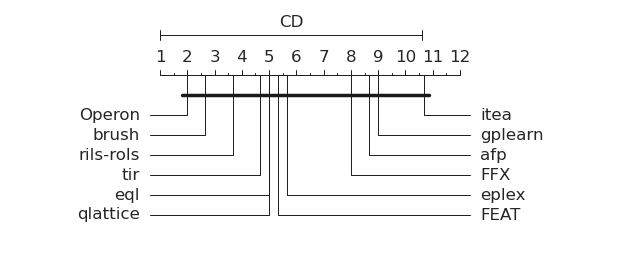

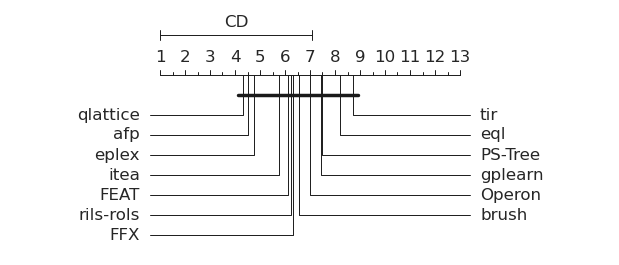

In [6]:
cd_plot(df_results[df_results.dataset.str.contains("_fri_")], "cd_fri_results")
cd_plot(df_results[~df_results.dataset.str.contains("_fri_")], "cd_nonfri_results")

## Clustermaps

/tmp/ipykernel_2191987/3287601311.py:5: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_clustermap = data[["dataset", "algorithm", "r2_test"]]\


saving ../figs/black-box//clustermap_Friedman.pdf


/tmp/ipykernel_2191987/3287601311.py:5: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_clustermap = data[["dataset", "algorithm", "r2_test"]]\


saving ../figs/black-box//clustermap_Non-Friedman.pdf


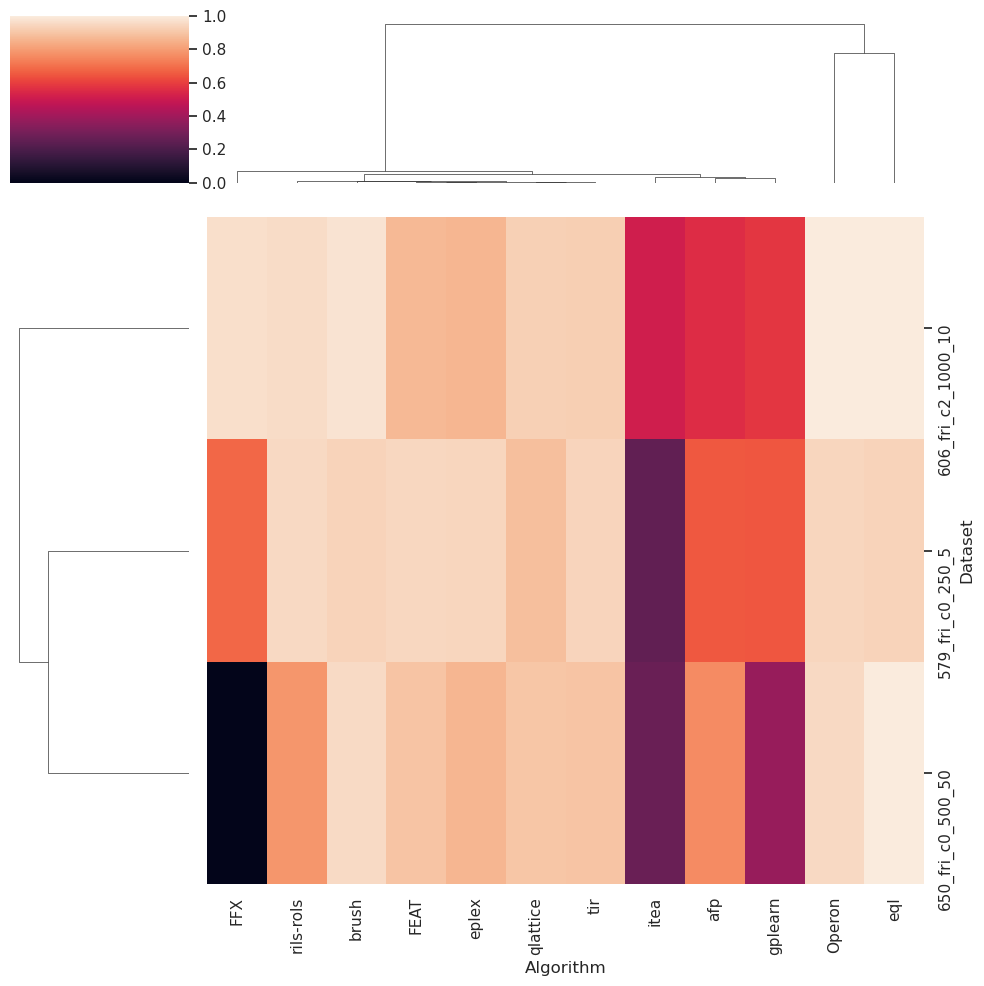

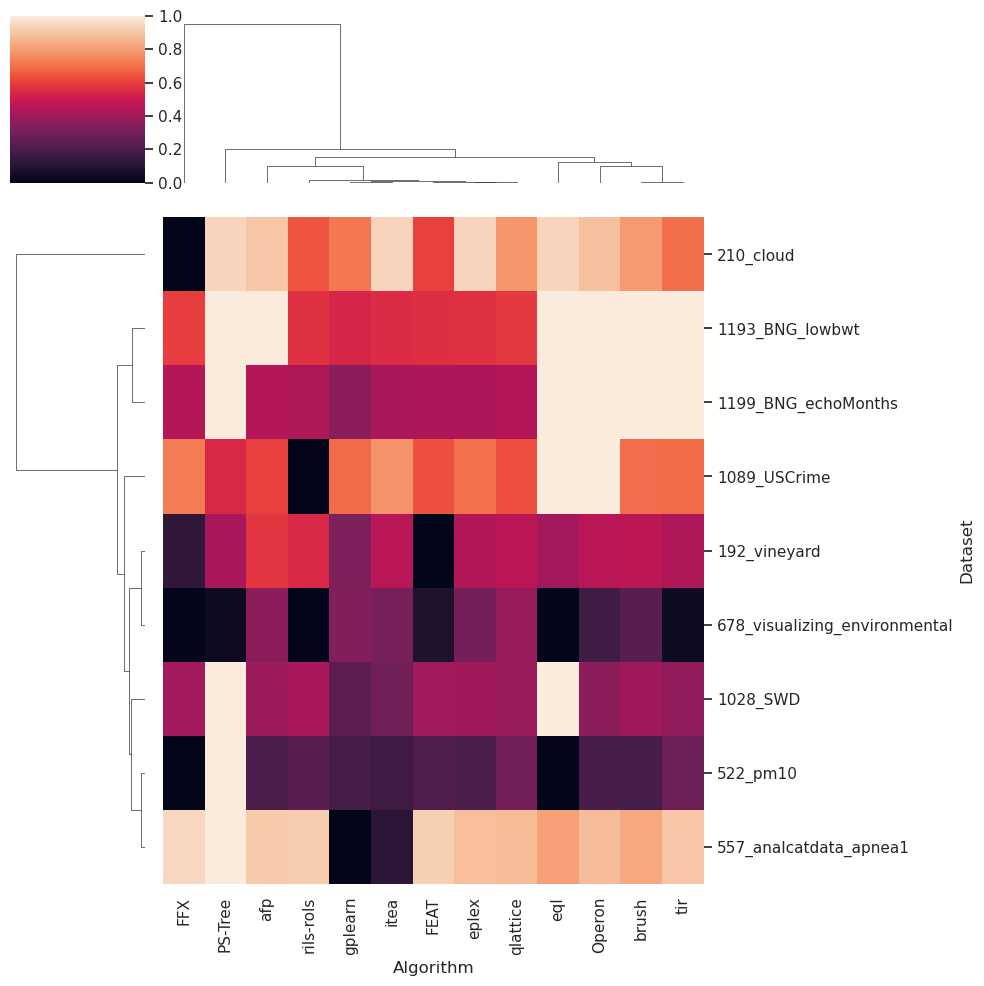

In [7]:
for (data, name) in [
    (df_sum[df_sum.dataset.str.contains("_fri_")].copy(), 'Friedman'),
    (df_sum[~df_sum.dataset.str.contains("_fri_")].copy(), 'Non-Friedman'),
]:
    df_clustermap = data[["dataset", "algorithm", "r2_test"]]\
            .groupby(["dataset", "algorithm"]).median().reset_index().pivot(
                "dataset", columns="algorithm").fillna(data["algorithm"].nunique())

    df_clustermap.columns = df_clustermap.columns.droplevel()
    g = sns.clustermap(df_clustermap, vmin=0, vmax=1.0)

    g.ax_heatmap.set_xlabel("Algorithm")
    g.ax_heatmap.set_ylabel("Dataset")

    save(name=f"clustermap_{name}")